In [1]:
import os
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging

# GLOBAL CONSTANTS
PATH_TO_FIGURES = "./fig/"
FIGSIZE = (9, 6)
LEGEND_FONTSIZE = 24
LABEL_FONTSIZE = 28
hatches = ['xx', '\\\\', '//', '--', '++', '||', 'o', 'O', '.', '*']
width = 0.35  # the width of the bars
line_width = 3.5
# colors = ['#7F449B', '#009D72', '#E5A023']
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
system = ["GAE", "vSoC", "Anbox", "Redroid", "MCon"]
font = {'family': 'Arial',
        'weight': 'normal',
        'size': LABEL_FONTSIZE}

# envsetup
plt.rc('font', **font)
plt.rcParams.update({'legend.handlelength': 1.3, 'legend.borderpad': 0.25,
                     "legend.labelspacing": 0.25, "legend.handletextpad": 0.5})
plt.rcParams['hatch.linewidth'] = line_width
pd.set_option("display.max_colwidth", 5000)
pd.set_option("display.max_columns", 10000)
pd.set_option("display.max_rows", 100)
os.makedirs(PATH_TO_FIGURES, exist_ok=True)
warnings.filterwarnings('ignore')

# refresh the fonts just installed
matplotlib.font_manager._load_fontmanager(try_read_cache=False)



In [2]:
# Hardcoded final plotting data (no file read, no post-processing)
x_proxy = np.array([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7, 1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8, 1.81, 1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.89, 1.9, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98, 1.99, 2.0, 2.01, 2.02, 2.03, 2.04, 2.05, 2.06, 2.07, 2.08, 2.09, 2.1, 2.11, 2.12, 2.13, 2.14, 2.15, 2.16, 2.17, 2.18, 2.19, 2.2, 2.21, 2.22, 2.23, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.3, 2.31, 2.32, 2.33, 2.34, 2.35, 2.36, 2.37, 2.38, 2.39, 2.4, 2.41, 2.42, 2.43, 2.44, 2.45, 2.46, 2.47, 2.48, 2.49, 2.5, 2.51, 2.52, 2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59, 2.6, 2.61, 2.62, 2.63, 2.64, 2.65, 2.66, 2.67, 2.68, 2.69, 2.7, 2.71, 2.72, 2.73, 2.74, 2.75, 2.76, 2.77, 2.78, 2.79, 2.8, 2.81, 2.82, 2.83, 2.84, 2.85, 2.86, 2.87, 2.88, 2.89, 2.9, 2.91, 2.92, 2.93, 2.94, 2.95, 2.96, 2.97, 2.98, 2.99, 3.0, 3.01, 3.02, 3.03, 3.04, 3.05, 3.06, 3.07, 3.08, 3.1, 3.11, 3.12, 3.13, 3.14, 3.15, 3.16, 3.17, 3.18, 3.19, 3.2, 3.21, 3.22, 3.23, 3.24, 3.25, 3.26, 3.27, 3.28, 3.29, 3.3, 3.31, 3.32, 3.33, 3.34, 3.35, 3.36, 3.37, 3.38, 3.39, 3.41, 3.42, 3.43, 3.45, 3.46, 3.47, 3.48, 3.49, 3.51, 3.52, 3.53, 3.54, 3.55, 3.56, 3.57, 3.58, 3.6, 3.61, 3.62, 3.63, 3.66, 3.67, 3.69, 3.71, 3.73, 3.74, 3.75, 3.76, 3.77, 3.81, 3.85, 3.88, 3.9, 3.91, 3.92, 3.94, 3.95, 3.98, 3.99, 4.0, 4.04, 4.05, 4.07, 4.08, 4.09, 4.1, 4.11, 4.14, 4.17, 4.18, 4.21, 4.24, 4.25, 4.29, 4.31, 4.33, 4.36, 4.38, 4.4, 4.42, 4.44, 4.45, 4.48, 4.52, 4.53, 4.56, 4.58, 4.59, 4.64, 4.65, 4.67, 4.68, 4.71, 4.73, 4.74, 4.75, 4.76, 4.79, 4.8, 4.84, 4.95, 4.97, 5.02, 5.03, 5.1, 5.12, 5.13, 5.18, 5.28, 5.35, 5.38, 5.45, 5.52, 5.58, 5.61, 5.63, 5.7, 5.76, 5.84, 5.89, 5.94, 5.98, 6.0, 6.06, 6.11, 6.24, 6.25, 6.26, 6.27, 6.29, 6.33, 6.38, 6.5, 6.54, 6.62, 6.63, 6.66, 6.72, 6.85, 6.93, 6.99, 7.11, 7.19, 7.25, 7.28, 7.3, 7.31, 7.38, 7.45, 7.51, 7.65, 7.69, 7.7, 7.84, 8.35, 8.51, 8.54, 8.71, 8.91, 8.94, 8.95, 9.12, 9.32, 9.55, 9.62, 9.83, 9.93, 10.28, 10.55, 10.61, 10.69, 10.78, 10.95, 11.12, 11.19, 11.23, 11.4, 11.5, 11.53, 11.61, 11.7, 11.92, 12.43, 12.72, 12.85, 13.11, 13.18, 13.43, 13.52, 13.63, 13.75, 14.07, 14.13, 14.49, 14.52, 15.18, 15.42, 15.55, 15.61, 16.1, 16.26, 16.41, 16.84, 16.87, 17.23, 17.31, 17.39, 17.47, 17.9, 18.11, 18.23, 18.24, 18.62, 18.87, 18.94, 18.96, 19.38, 19.66, 19.75, 20.14, 20.68, 20.73, 20.88, 20.96, 21.35, 21.83, 22.93, 23.12, 23.19, 23.41, 24.3, 24.38, 24.93, 25.88, 26.51, 28.31, 28.95, 30.31, 30.55, 31.78, 34.05, 35.43, 35.44, 35.65, 36.28, 37.33, 37.69, 38.17, 38.38, 38.76, 40.0, 40.32, 40.34, 40.46, 40.97, 42.8, 43.01, 44.26, 45.6, 46.02, 46.43, 47.37, 47.53, 47.69, 47.86, 47.89, 48.31, 48.67, 48.89, 49.31, 49.91, 50.32, 51.03, 51.7, 52.49, 52.58, 52.79, 53.04, 53.38, 54.02, 55.53, 56.04, 56.22, 56.79, 56.82, 57.29, 57.95, 58.26, 58.88, 60.02, 60.15, 60.68, 60.88, 62.37, 63.21, 64.01, 65.03, 65.11, 66.12, 66.77, 67.66, 68.38, 69.37, 69.48, 69.72, 70.33, 70.36, 70.44, 70.88, 71.18, 71.36, 72.93, 73.58, 73.69, 74.03, 74.46, 74.71, 75.14, 75.28, 75.47, 75.75, 78.21, 78.63, 80.04, 81.09, 83.73, 84.97, 85.21, 88.58, 88.8, 89.5, 89.55, 89.69, 92.81, 95.07, 96.11, 96.55, 97.63, 98.28, 101.82, 103.71, 104.05, 105.64, 109.3, 111.99, 114.53, 114.89, 114.99, 116.17, 116.88, 118.57, 120.4, 120.46, 121.8, 121.95, 123.38, 138.08, 139.08, 191.53, 192.52, 196.38, 197.72, 201.62, 204.58, 209.27, 211.68, 212.85, 216.5, 218.61, 221.26, 221.55, 222.77, 222.82, 223.78, 225.85, 230.45, 234.04, 235.3, 235.35, 235.39, 235.59, 236.59, 237.62, 237.88, 239.28, 241.55, 242.62, 246.92, 247.14, 251.45, 255.97, 264.03, 266.88, 267.39, 274.3, 274.33, 277.32, 279.09, 280.55, 282.74, 288.83, 297.09, 298.11, 310.0, 310.63, 312.0, 312.07, 320.2, 323.0, 323.75, 332.05, 334.36, 336.26, 344.62, 357.2, 386.48])
cdf_proxy = np.array([0.014990330568056534, 0.0329212528692006, 0.03803430389126859, 0.04228614289070831, 0.04420557031574762, 0.04524028990222126, 0.04574996837101701, 0.046007518661099964, 0.046179218854488606, 0.046358148529704137, 0.04651810081512408, 0.046626543042527425, 0.046701548916481414, 0.04676390319723834, 0.046819027996168376, 0.04687324910987005, 0.046918433371288114, 0.04695458078042256, 0.04699072818955701, 0.04702326085777802, 0.04705037141462886, 0.04707115617488117, 0.04709465199081856, 0.04712899202949629, 0.04718050208751288, 0.04722297529324586, 0.04726364112852211, 0.04731786224222379, 0.047375698096838906, 0.047414556561658446, 0.04746154819353323, 0.04753022827088869, 0.04759619729255905, 0.04764318892443384, 0.04780675595076723, 0.04841764716513944, 0.050172603878617, 0.053395145402953245, 0.0571770680836451, 0.061959370312132875, 0.07055522420430516, 0.08246127708796472, 0.09356124274792604, 0.1045834914782483, 0.11811979251387157, 0.13333062227764825, 0.1477046395199624, 0.1634143035297945, 0.18453433100182545, 0.20667010067053443, 0.22723345804189485, 0.24561080084584938, 0.2663594136890238, 0.2920999837336659, 0.32158181062372354, 0.3546467494442336, 0.3865459343201576, 0.4153274051582353, 0.4413571544759529, 0.4637360154710911, 0.48364329736666123, 0.5023920547994722, 0.5211064721936055, 0.5384075258905818, 0.555425726111081, 0.5731578376619856, 0.5919328019664191, 0.611737063745956, 0.6315557844891467, 0.6504635905221493, 0.6679164633374903, 0.6837562580202065, 0.6990556489363625, 0.7139980841873159, 0.7289703410508052, 0.7439895895461692, 0.7581801586871261, 0.7711878038641581, 0.7845515010211643, 0.7983805960707766, 0.8111794899600571, 0.8233539373565399, 0.8353810840607999, 0.8470747709157946, 0.8578801351913101, 0.8679986986932712, 0.87740154349437, 0.8860245079433932, 0.8936904697355817, 0.9005196190063077, 0.9067469139149451, 0.9126190605288366, 0.9178929675215529, 0.922793652514956, 0.9272036364293589, 0.9313172115888594, 0.9350882900468109, 0.9385602486941749, 0.9418035749787634, 0.944681812431094, 0.947616078367583, 0.950345207757234, 0.9528267273943141, 0.955145583690289, 0.9573108134974426, 0.9594001337454138, 0.9614072186376041, 0.9633158018399032, 0.9650698548681523, 0.9667263098917385, 0.9683104700970558, 0.9697211227385277, 0.971145330658425, 0.9724565779247772, 0.9737081819660576, 0.9748784543367854, 0.9759673950369607, 0.9770707947007898, 0.9780756926747275, 0.9790489616656726, 0.9799906016736251, 0.9808500063257966, 0.9816886262177158, 0.9824802544777603, 0.9832520016627808, 0.9839613945670445, 0.9847015127690723, 0.9853449366516654, 0.985986553163802, 0.9865585859133547, 0.9870890491424027, 0.9876131865748522, 0.9881201539879629, 0.988640676679499, 0.9891358961846409, 0.9895741835203962, 0.9899754197617886, 0.9903947297077482, 0.9907543964286359, 0.9911258110574924, 0.9914719224999549, 0.9917882123298812, 0.9920864284552404, 0.9923701856169459, 0.9926738238536753, 0.9929440257369553, 0.9931925391747547, 0.9934329194454987, 0.9936606481230458, 0.9938775325778525, 0.9940908022917457, 0.9943113014874659, 0.9945272822570442, 0.9946944640242911, 0.9948697789585932, 0.9950351533553833, 0.995199624066945, 0.9953306584250574, 0.9954734406911384, 0.9956315856061017, 0.9957761752426395, 0.9958972690632399, 0.9960228813099821, 0.996137649333984, 0.9962542247284426, 0.9963563411592474, 0.9964367691445716, 0.9965217155560375, 0.9966220246163856, 0.9967214299915054, 0.9968009542916012, 0.9968777675360119, 0.996955484465651, 0.9970178387464078, 0.9970810967123931, 0.9971533915306621, 0.9972112273852771, 0.9972726779808058, 0.9973395506877044, 0.9973847349491225, 0.9974317265809973, 0.9974841403242423, 0.9975401688084007, 0.9975998120334725, 0.9976513220914891, 0.9977001210938206, 0.9977516311518372, 0.9978040448950821, 0.9978347701928464, 0.9978727249724376, 0.9979133908077139, 0.9979522492725333, 0.9979820708850693, 0.9980272551464874, 0.9980579804442516, 0.9980986462795279, 0.9981402158000325, 0.9981799779500804, 0.9982224511558134, 0.9982567911944912, 0.9982920349183972, 0.998326374957075, 0.9983625223662094, 0.9984049955719424, 0.9984357208697067, 0.9984619277413291, 0.9984953640947785, 0.9985206672811726, 0.9985522962641653, 0.998576695765331, 0.9986001915812684, 0.9986200726562924, 0.998639050046088, 0.9986553163801984, 0.9986761011404508, 0.9986932711597897, 0.9987149596052703, 0.9987321296246091, 0.9987574328110033, 0.9987764102007989, 0.9987881581087675, 0.9988008097019646, 0.9988170760360752, 0.9988351497406424, 0.9988478013338394, 0.9988613566122648, 0.9988740082054619, 0.9988821413725171, 0.9988920819100291, 0.9989110592998247, 0.9989282293191636, 0.9989399772271322, 0.9989526288203293, 0.9989607619873846, 0.9989707025248965, 0.9989842578033219, 0.9989941983408339, 0.999006849934031, 0.9990213088976848, 0.9990321531204251, 0.9990411899727087, 0.9990484194545356, 0.9990610710477327, 0.9990728189557013, 0.9990809521227566, 0.9990927000307253, 0.9991035442534656, 0.9991180032171194, 0.9991261363841747, 0.9991351732364583, 0.9991487285148837, 0.9991586690523957, 0.9991686095899076, 0.9991767427569629, 0.9991866832944749, 0.9992029496285854, 0.9992165049070107, 0.9992228307036093, 0.9992381933524914, 0.9992508449456885, 0.9992607854832005, 0.9992707260207124, 0.9992788591877677, 0.9992887997252797, 0.9992969328923349, 0.9993068734298469, 0.9993141029116738, 0.9993249471344141, 0.9993330803014694, 0.999342117153753, 0.99934934663558, 0.9993619982287769, 0.9993683240253755, 0.9993728424515173, 0.9993755535072024, 0.9993809756185725, 0.9993900124708561, 0.9993909161560846, 0.9993918198413129, 0.9993945308969979, 0.9994008566935965, 0.99940447143451, 0.9994098935458801, 0.9994162193424786, 0.9994198340833921, 0.9994225451390771, 0.9994243525095339, 0.9994270635652189, 0.9994333893618175, 0.9994388114731877, 0.9994433298993295, 0.9994460409550145, 0.9994514630663848, 0.9994559814925266, 0.9994595962334399, 0.9994659220300385, 0.9994713441414087, 0.9994758625675505, 0.9994785736232356, 0.9994812846789206, 0.999482188364149, 0.9994848994198341, 0.9994876104755192, 0.9994903215312042, 0.9994912252164326, 0.999494839957346, 0.9995011657539445, 0.9995065878653148, 0.9995092989209998, 0.9995120099766849, 0.9995156247175984, 0.9995183357732834, 0.9995210468289686, 0.9995237578846536, 0.9995291799960238, 0.999534602107394, 0.9995364094778507, 0.9995382168483073, 0.9995418315892208, 0.9995454463301343, 0.9995481573858194, 0.9995490610710477, 0.9995544831824179, 0.9995562905528746, 0.999557194238103, 0.999559905293788, 0.9995617126642448, 0.9995653274051582, 0.999567134775615, 0.9995689421460717, 0.9995716532017568, 0.9995725568869851, 0.9995752679426702, 0.9995806900540404, 0.9995815937392687, 0.9995843047949539, 0.9995852084801822, 0.9995906305915524, 0.9995960527029225, 0.9995978600733793, 0.9996014748142927, 0.999602378499521, 0.9996041858699778, 0.9996050895552061, 0.9996078006108912, 0.9996096079813479, 0.9996114153518046, 0.9996132227222614, 0.9996141264074897, 0.9996168374631749, 0.9996195485188599, 0.9996204522040882, 0.9996213558893167, 0.9996231632597734, 0.9996240669450017, 0.9996258743154585, 0.9996276816859152, 0.9996303927416003, 0.999632200112057, 0.9996349111677421, 0.9996367185381988, 0.9996394295938839, 0.9996412369643406, 0.9996421406495689, 0.9996439480200257, 0.9996475627609391, 0.9996484664461674, 0.9996493701313959, 0.9996502738166242, 0.9996520811870809, 0.9996529848723092, 0.9996538885575377, 0.9996565996132227, 0.999657503298451, 0.9996584069836795, 0.9996593106689078, 0.9996611180393645, 0.9996629254098213, 0.9996638290950496, 0.999664732780278, 0.9996656364655063, 0.9996674438359631, 0.9996692512064198, 0.9996701548916481, 0.9996710585768765, 0.9996719622621049, 0.9996728659473332, 0.9996746733177899, 0.9996755770030183, 0.9996764806882467, 0.9996773843734751, 0.9996782880587034, 0.9996791917439317, 0.9996809991143885, 0.9996819027996169, 0.9996828064848452, 0.9996837101700735, 0.9996846138553019, 0.9996855175405303, 0.9996864212257587, 0.999687324910987, 0.9996882285962153, 0.9996891322814437, 0.999690035966672, 0.9996909396519005, 0.9996918433371288, 0.9996927470223572, 0.9996936507075855, 0.9996945543928139, 0.9996954580780423, 0.9996963617632706, 0.999697265448499, 0.9996981691337273, 0.9996990728189556, 0.9996999765041841, 0.9997017838746408, 0.9997026875598691, 0.9997044949303259, 0.9997063023007826, 0.9997072059860109, 0.9997081096712394, 0.9997090133564677, 0.999709917041696, 0.9997108207269244, 0.9997117244121527, 0.9997126280973812, 0.9997135317826095, 0.9997144354678379, 0.9997153391530662, 0.9997162428382945, 0.999717146523523, 0.9997189538939797, 0.9997216649496647, 0.9997225686348931, 0.9997234723201215, 0.9997243760053498, 0.9997252796905782, 0.9997261833758065, 0.9997270870610349, 0.9997279907462633, 0.9997288944314916, 0.99972979811672, 0.9997307018019483, 0.9997316054871767, 0.9997325091724051, 0.9997334128576334, 0.9997343165428618, 0.9997352202280901, 0.9997361239133186, 0.9997370275985469, 0.9997379312837752, 0.9997388349690036, 0.9997397386542319, 0.9997406423394604, 0.9997415460246887, 0.999742449709917, 0.9997433533951454, 0.9997442570803737, 0.9997451607656022, 0.9997469681360589, 0.9997478718212872, 0.9997487755065155, 0.9997505828769723, 0.9997514865622007, 0.9997532939326573, 0.9997541976178858, 0.9997551013031141, 0.9997560049883425, 0.9997569086735708, 0.9997578123587992, 0.9997587160440276, 0.9997605234144843, 0.9997614270997126, 0.999762330784941, 0.9997632344701693, 0.9997641381553977, 0.9997650418406261, 0.9997659455258544, 0.9997668492110828, 0.9997677528963111, 0.9997686565815396, 0.9997695602667679, 0.9997704639519962, 0.9997713676372246, 0.9997722713224529, 0.9997731750076814, 0.9997740786929097, 0.999774982378138, 0.9997758860633664, 0.9997767897485947, 0.9997776934338232, 0.9997785971190515, 0.9997795008042799, 0.9997804044895082, 0.9997813081747365, 0.999782211859965, 0.9997831155451933, 0.9997840192304217, 0.99978492291565, 0.9997858266008783, 0.9997867302861068, 0.9997876339713351, 0.9997894413417918, 0.9997903450270201, 0.9997912487122486, 0.9997921523974769, 0.9997930560827053, 0.9997939597679336, 0.999794863453162, 0.9997957671383904, 0.9997966708236187, 0.9997975745088471, 0.9997984781940754, 0.9997993818793038, 0.9998002855645322, 0.9998011892497605, 0.9998020929349889, 0.9998029966202172, 0.9998039003054456, 0.999804803990674, 0.9998057076759024, 0.9998066113611307, 0.999807515046359, 0.9998084187315874, 0.9998093224168157, 0.9998102261020442, 0.9998111297872725, 0.9998120334725008, 0.9998129371577292, 0.9998138408429575, 0.999814744528186, 0.9998156482134143, 0.9998165518986427, 0.999817455583871, 0.9998183592690993, 0.9998192629543278, 0.9998201666395561, 0.9998210703247845, 0.9998228776952411, 0.9998237813804696, 0.9998246850656979, 0.9998255887509263, 0.9998264924361546, 0.999827396121383, 0.9998282998066114, 0.9998292034918397, 0.9998301071770681, 0.9998310108622964, 0.9998319145475248, 0.9998328182327532, 0.9998337219179815, 0.9998346256032099, 0.9998355292884382, 0.9998364329736666, 0.999837336658895, 0.9998382403441234, 0.9998391440293517, 0.99984004771458, 0.9998409513998084, 0.9998418550850368, 0.9998427587702652, 0.9998436624554935, 0.9998445661407218, 0.9998454698259502, 0.9998463735111786, 0.999847277196407, 0.9998481808816353, 0.9998490845668637, 0.999849988252092, 0.9998508919373204, 0.9998517956225488, 0.9998526993077771, 0.9998536029930055, 0.9998545066782338, 0.9998554103634621, 0.9998563140486906, 0.9998572177339189, 0.9998581214191473, 0.9998590251043756, 0.9998599287896041, 0.9998608324748324, 0.9998617361600607, 0.9998626398452891, 0.9998635435305174, 0.9998644472157459, 0.9998653509009742, 0.9998662545862025, 0.9998671582714309, 0.9998680619566592, 0.9998689656418877, 0.999869869327116, 0.9998707730123444, 0.9998716766975727, 0.999872580382801, 0.9998734840680295, 0.9998743877532578, 0.9998752914384862, 0.9998761951237145, 0.9998770988089428, 0.9998780024941712, 0.9998789061793996, 0.999879809864628, 0.9998807135498563, 0.9998816172350847, 0.999882520920313, 0.9998834246055414, 0.9998843282907698, 0.9998852319759981, 0.9998861356612265, 0.9998870393464548, 0.9998879430316832, 0.9998888467169116, 0.9998897504021399, 0.9998906540873683, 0.9998915577725966, 0.9998924614578251, 0.9998933651430534, 0.9998942688282817, 0.9998951725135101, 0.9998960761987384, 0.9998969798839669, 0.9998978835691952, 0.9998987872544235, 0.9998996909396519, 0.9999005946248802, 0.9999014983101087, 0.999902401995337, 0.9999033056805653, 0.9999042093657937, 0.999905113051022, 0.9999060167362505, 0.9999069204214788, 0.9999078241067072, 0.9999087277919355, 0.9999096314771638, 0.9999105351623923, 0.9999114388476206, 0.999912342532849, 0.9999132462180773, 0.9999141499033056, 0.999915053588534, 0.9999159572737624, 0.9999168609589908, 0.9999177646442191, 0.9999186683294475, 0.9999195720146759, 0.9999204756999042, 0.9999213793851326, 0.9999222830703609, 0.9999231867555893, 0.9999240904408176, 0.999924994126046, 0.9999258978112744, 0.9999268014965027, 0.9999277051817311, 0.9999286088669594, 0.9999295125521879, 0.9999304162374162, 0.9999313199226445, 0.9999322236078729, 0.9999331272931012, 0.9999340309783297, 0.999934934663558, 0.9999358383487863, 0.9999367420340147, 0.999937645719243, 0.9999385494044715, 0.9999394530896998, 0.9999403567749282, 0.9999412604601565, 0.9999421641453848, 0.9999430678306133, 0.9999439715158416, 0.99994487520107, 0.9999457788862983, 0.9999466825715266, 0.9999475862567551, 0.9999484899419834, 0.9999493936272118, 0.9999502973124401, 0.9999512009976685, 0.9999521046828969, 0.9999530083681252, 0.9999539120533536, 0.9999548157385819, 0.9999557194238103, 0.9999566231090387, 0.999957526794267, 0.9999584304794954, 0.9999593341647237, 0.9999602378499521, 0.9999611415351805, 0.9999620452204089, 0.9999629489056372, 0.9999638525908655, 0.9999647562760939, 0.9999656599613223, 0.9999665636465507, 0.999967467331779, 0.9999683710170073, 0.9999692747022357, 0.999970178387464, 0.9999710820726925, 0.9999719857579208, 0.9999728894431492, 0.9999737931283775, 0.9999746968136058, 0.9999756004988343, 0.9999765041840626, 0.999977407869291, 0.9999783115545193, 0.9999792152397476, 0.9999801189249761, 0.9999810226102044, 0.9999819262954328, 0.9999828299806611, 0.9999837336658896, 0.9999846373511179, 0.9999855410363462, 0.9999864447215746, 0.9999873484068029, 0.9999882520920313, 0.9999891557772597, 0.999990059462488, 0.9999909631477164, 0.9999918668329447, 0.9999927705181731, 0.9999936742034015, 0.9999945778886299, 0.9999954815738582, 0.9999963852590865, 0.9999972889443149, 0.9999981926295433, 0.9999990963147717, 1.0])
x_proxy_i = np.array([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7, 1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8, 1.81, 1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.89, 1.9, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98, 1.99, 2.0, 2.01, 2.02, 2.03, 2.04, 2.05, 2.06, 2.07, 2.08, 2.09, 2.1, 2.11, 2.12, 2.13, 2.14, 2.15, 2.16, 2.17, 2.18, 2.19, 2.2, 2.21, 2.22, 2.23, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.3, 2.31, 2.32, 2.33, 2.34, 2.35, 2.36, 2.37, 2.38, 2.39, 2.4, 2.41, 2.42, 2.43, 2.44, 2.45, 2.46, 2.47, 2.48, 2.49, 2.5, 2.51, 2.52, 2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59, 2.6, 2.61, 2.62, 2.63, 2.64, 2.65, 2.66, 2.67, 2.68, 2.69, 2.7, 2.71, 2.72, 2.73, 2.74, 2.75, 2.76, 2.77, 2.78, 2.79, 2.8, 2.81, 2.82, 2.83, 2.84, 2.85, 2.86, 2.87, 2.88, 2.89, 2.9, 2.91, 2.92, 2.93, 2.94, 2.95, 2.96, 2.97, 2.98, 2.99, 3.0, 3.01, 3.02, 3.03, 3.04, 3.05, 3.06, 3.07, 3.08, 3.1, 3.11, 3.12, 3.13, 3.14, 3.15, 3.16, 3.17, 3.18, 3.19, 3.2, 3.21, 3.22, 3.23, 3.24, 3.25, 3.26, 3.27, 3.28, 3.29, 3.3, 3.31, 3.32, 3.33, 3.34, 3.35, 3.36, 3.37, 3.38, 3.39, 3.41, 3.42, 3.43, 3.45, 3.46, 3.47, 3.48, 3.49, 3.51, 3.52, 3.53, 3.54, 3.55, 3.56, 3.57, 3.58, 3.6, 3.61, 3.62, 3.63, 3.66, 3.67, 3.69, 3.71, 3.73, 3.74, 3.75, 3.76, 3.77, 3.81, 3.85, 3.88, 3.9, 3.91, 3.92, 3.94, 3.95, 3.98, 3.99, 4.0, 4.04, 4.05, 4.07, 4.08, 4.09, 4.1, 4.11, 4.14, 4.17, 4.18, 4.21, 4.24, 4.25, 4.29, 4.31, 4.33, 4.36, 4.38, 4.4, 4.42, 4.44, 4.45, 4.48, 4.52, 4.53, 4.56, 4.58, 4.59, 4.64, 4.65, 4.67, 4.68, 4.71, 4.73, 4.74, 4.75, 4.76, 4.79, 4.8, 4.84, 4.95, 4.97, 5.02, 5.03, 5.1, 5.12, 5.13, 5.18, 5.28, 5.35, 5.38, 5.45, 5.52, 5.58, 5.61, 5.63, 5.7, 5.76, 5.84, 5.89, 5.94, 5.98, 6.0, 6.06, 6.11, 6.24, 6.25, 6.26, 6.27, 6.29, 6.33, 6.38, 6.5, 6.54, 6.62, 6.63, 6.66, 6.72, 6.85, 6.93, 6.99, 7.11, 7.19, 7.25, 7.28, 7.3, 7.31, 7.38, 7.45, 7.51, 7.65, 7.69, 7.7, 7.84, 8.35, 8.51, 8.54, 8.71, 8.91, 8.94, 8.95, 9.12, 9.32, 9.55, 9.62, 9.83, 9.93, 10.28, 10.55, 10.61, 10.69, 10.78, 10.95, 11.12, 11.19, 11.23, 11.4, 11.5, 11.53, 11.61, 11.7, 11.92, 12.43, 12.72, 12.85, 13.11, 13.18, 13.43, 13.52, 13.63, 13.75, 14.07, 14.13, 14.49, 14.52, 15.18, 15.42, 15.55, 15.61, 16.1, 16.26, 16.41, 16.84, 16.87, 17.23, 17.31, 17.39, 17.47, 17.9, 18.11, 18.23, 18.24, 18.62, 18.87, 18.94, 18.96, 19.38, 19.66, 19.75, 20.14, 20.68, 20.73, 20.88, 20.96, 21.35, 21.83, 22.93, 23.12, 23.19, 23.41, 24.3, 24.38, 24.93, 25.88, 26.51, 28.31, 28.95, 30.31, 30.55, 31.78, 34.05, 35.43, 35.44, 35.65, 36.28, 37.33, 37.69, 38.17, 38.38, 38.76, 40.0, 40.32, 40.34, 40.46, 40.97, 42.8, 43.01, 44.26, 45.6, 46.02, 46.43, 47.37, 47.53, 47.69, 47.86, 47.89, 48.31, 48.67, 48.89, 49.31, 49.91, 50.32, 51.03, 51.7, 52.49, 52.58, 52.79, 53.04, 53.38, 54.02, 55.53, 56.04, 56.22, 56.79, 56.82, 57.29, 57.95, 58.26, 58.88, 60.02, 60.15, 60.68, 60.88, 62.37, 63.21, 64.01, 65.03, 65.11, 66.12, 66.77, 67.66, 68.38, 69.37, 69.48, 69.72, 70.33, 70.36, 70.44, 70.88, 71.18, 71.36, 72.93, 73.58, 73.69, 74.03, 74.46, 74.71, 75.14, 75.28, 75.47, 75.75, 78.21, 78.63, 80.04, 81.09, 83.73, 84.97, 85.21, 88.58, 88.8, 89.5, 89.55, 89.69, 92.81, 95.07, 96.11, 96.55, 97.63, 98.28, 101.82, 103.71, 104.05, 105.64, 109.3, 111.99, 114.53, 114.89, 114.99, 116.17, 116.88, 118.57, 120.4, 120.46, 121.8, 121.95, 123.38, 138.08, 139.08, 191.53, 192.52, 196.38, 197.72, 201.62, 204.58, 209.27, 211.68, 212.85, 216.5, 218.61, 221.26, 221.55, 222.77, 223.78, 230.45, 234.04, 235.3, 235.35, 235.39, 235.59, 237.62, 237.88, 239.28, 241.55, 242.62, 246.92, 247.14, 251.45, 255.97, 264.03, 266.88, 267.39, 274.3, 274.33, 279.09, 280.55, 282.74, 288.83, 298.11, 310.0, 310.63, 312.0, 312.07, 320.2, 323.75, 332.05, 336.26, 344.62])
cdf_proxy_i = np.array([0.00046744094063500056, 0.0010238281331317219, 0.001232946448678959, 0.0014098927156804672, 0.0015243873590343843, 0.0015944088764574412, 0.001659699210270832, 0.0017202583604745566, 0.0017571615926299513, 0.0018271831100530082, 0.0018934196805883321, 0.0019378928065191924, 0.001983312169171986, 0.00202589282165898, 0.002055226160038909, 0.00209686057580397, 0.002129032624349699, 0.0021555272525638283, 0.002185806827665691, 0.0022141939293236867, 0.00223879608409395, 0.002256774581810681, 0.002275699316249345, 0.002305978891351207, 0.0023551832008917336, 0.0023987100901006605, 0.0024375057956999217, 0.002491441288850114, 0.0025501079656099724, 0.002589849907931167, 0.0026381079807497603, 0.0027071832614508837, 0.002776258542152007, 0.0028245166149706005, 0.002993892988196643, 0.003629764065335753, 0.00546546330588616, 0.008838797219578016, 0.012798797900868457, 0.01780439015989508, 0.026804047622201743, 0.039270716433671644, 0.05089334208917713, 0.06243459138659637, 0.07660827124443376, 0.09253438151129144, 0.10758522281036091, 0.12403270951100379, 0.14614815417602653, 0.16932622267978026, 0.1908578392873702, 0.21009956302788182, 0.23182421192674613, 0.25877587247756945, 0.28964589929391815, 0.32426964718617585, 0.35767085723369585, 0.38780755059054633, 0.41506200689238826, 0.438495559311064, 0.45934020805853043, 0.47897367380192235, 0.498569290076437, 0.516686884591292, 0.534506414538738, 0.5530734714965112, 0.5727315393946735, 0.5934683171558395, 0.6142192884678346, 0.634016453164121, 0.6522911229748168, 0.6688767602368619, 0.6848965479391911, 0.7005425721363565, 0.7162198221453457, 0.7319462764638756, 0.7468050317083925, 0.7604261093206209, 0.7744190579645691, 0.7889002647570348, 0.8023008692130528, 0.8150485703309368, 0.8276420348631458, 0.8398872842816834, 0.8512004905291166, 0.8617955031046027, 0.8716410961963176, 0.8806700869970042, 0.8886970131091635, 0.8958496164902566, 0.9023710799778202, 0.9085187799602202, 0.9140410174694223, 0.919173405449188, 0.9237900944155001, 0.92809736397374, 0.9320460098143672, 0.9356814513000347, 0.9390774948950529, 0.9420912588544101, 0.9451636894905272, 0.9480213243907655, 0.950620636665916, 0.9530486800943966, 0.9553158632801485, 0.9575026163445362, 0.9596042081039498, 0.9616036062973946, 0.963440251774667, 0.9651747036859706, 0.9668344028962413, 0.9683114784191791, 0.9698036937296678, 0.9711766832131928, 0.9724872210730703, 0.9737125976279738, 0.9748528128779033, 0.9760081679153837, 0.9770603831501734, 0.9780794800996955, 0.9790654587639499, 0.9799653298865084, 0.9808434375644624, 0.9816723409328758, 0.9824785346199629, 0.9832213304466805, 0.9839962983219438, 0.9846700188679602, 0.9853418469405328, 0.9859408147855165, 0.9864962557412913, 0.9870450730400125, 0.9875759118410171, 0.9881209441928506, 0.98863948191647, 0.9890984067266076, 0.9895185358311459, 0.9899575896701229, 0.9903341918854524, 0.9907230951781669, 0.9910855038426674, 0.991416686695344, 0.9917289448135819, 0.9920260631442689, 0.9923439986828385, 0.9926269234626965, 0.9928871385612281, 0.9931388375292624, 0.9933763429464676, 0.9936034397597315, 0.9938267516261078, 0.9940576333862595, 0.9942837839628016, 0.9944588377563592, 0.9946424076804142, 0.994815569000528, 0.9949877840839199, 0.9951249884086002, 0.9952716551004998, 0.9954372465268381, 0.9955886444023474, 0.9957154401230864, 0.9958460207907133, 0.9959661928543988, 0.9960882573915282, 0.9961951821411066, 0.9962793972093587, 0.9963683434612204, 0.9964743219740769, 0.9965784080134895, 0.9966616768450197, 0.996742106966384, 0.9968234833244702, 0.9968887736582837, 0.9969550102288189, 0.9970307091665737, 0.9970912683167773, 0.9971556124138689, 0.9972256339312918, 0.9972729457673886, 0.997322150076929, 0.9973770318068012, 0.9974356984835611, 0.9974981501072087, 0.9975520856003588, 0.9976031823833432, 0.9976571178764934, 0.9977119996063655, 0.9977441716549112, 0.9977839135972324, 0.9978264942497195, 0.9978662361920406, 0.9978965157671424, 0.9979438276032392, 0.9979759996517849, 0.9980185803042719, 0.9980621071934808, 0.9981037416092459, 0.9981482147351767, 0.9981841717306101, 0.9982210749627656, 0.998257031958199, 0.9982948814270763, 0.9983393545530073, 0.9983715266015529, 0.998398967466489, 0.9984339782252005, 0.9984604728534147, 0.9984935911386823, 0.9985191395301746, 0.9985437416849448, 0.9985645588928274, 0.998584429863988, 0.9986014621249827, 0.9986232255695872, 0.998641204067304, 0.9986639137486303, 0.9986818922463471, 0.9987083868745612, 0.9987282578457218, 0.9987405589231069, 0.998753806237214, 0.9987708384982088, 0.9987897632326475, 0.9988030105467545, 0.9988172040975835, 0.9988304514116906, 0.9988389675421879, 0.9988493761461292, 0.9988692471172899, 0.9988872256150065, 0.9988995266923917, 0.9989127740064988, 0.9989212901369962, 0.9989316987409375, 0.9989458922917664, 0.9989563008957076, 0.9989695482098148, 0.9989846879973657, 0.9989960428380289, 0.9990055052052482, 0.9990130750990237, 0.9990263224131307, 0.9990386234905159, 0.9990471396210132, 0.9990594406983984, 0.9990707955390616, 0.9990859353266125, 0.99909445145711, 0.9991039138243293, 0.9991181073751583, 0.9991285159790996, 0.9991389245830408, 0.9991474407135382, 0.9991578493174794, 0.9991748815784742, 0.9991890751293032, 0.9991956987863568, 0.9992117848106297, 0.9992250321247367, 0.999235440728678, 0.9992458493326193, 0.9992543654631166, 0.9992647740670579, 0.9992732901975553, 0.9992836988014966, 0.9992912686952721, 0.9993026235359352, 0.9993111396664326, 0.9993206020336519, 0.9993281719274274, 0.9993414192415345, 0.999348042898588, 0.9993527740821977, 0.9993556127923635, 0.999361290212695, 0.9993707525799144, 0.9993716988166363, 0.9993726450533583, 0.9993754837635241, 0.9993821074205776, 0.9993858923674653, 0.999391569787797, 0.9993981934448505, 0.9994019783917382, 0.999404817101904, 0.9994067095753478, 0.9994095482855136, 0.9994161719425673, 0.9994218493628988, 0.9994265805465085, 0.9994294192566743, 0.9994350966770059, 0.9994398278606156, 0.9994436128075033, 0.9994502364645568, 0.9994559138848884, 0.9994606450684981, 0.9994634837786639, 0.9994663224888297, 0.9994672687255516, 0.9994701074357174, 0.9994729461458832, 0.999475784856049, 0.9994767310927709, 0.9994805160396587, 0.9994871396967122, 0.9994928171170439, 0.9994956558272096, 0.9994984945373754, 0.9995022794842632, 0.9995051181944289, 0.9995079569045947, 0.9995107956147605, 0.9995164730350922, 0.9995221504554237, 0.9995240429288677, 0.9995249891655895, 0.9995287741124773, 0.999532559059365, 0.9995353977695308, 0.9995363440062527, 0.9995420214265843, 0.9995439139000282, 0.9995448601367501, 0.999547698846916, 0.9995495913203598, 0.9995533762672475, 0.9995552687406914, 0.9995571612141353, 0.9995599999243011, 0.999560946161023, 0.9995637848711888, 0.9995694622915204, 0.9995704085282423, 0.9995732472384081, 0.9995741934751301, 0.9995798708954616, 0.9995855483157933, 0.9995874407892371, 0.9995912257361249, 0.9995921719728468, 0.9995940644462906, 0.9995950106830126, 0.9995978493931784, 0.9995997418666223, 0.9996016343400661, 0.99960352681351, 0.9996044730502319, 0.9996073117603977, 0.9996101504705636, 0.9996110967072854, 0.9996120429440074, 0.9996139354174512, 0.9996148816541732, 0.9996167741276171, 0.9996186666010609, 0.9996215053112267, 0.9996233977846706, 0.9996262364948364, 0.9996281289682802, 0.9996309676784461, 0.9996328601518899, 0.9996338063886119, 0.9996356988620557, 0.9996394838089434, 0.9996404300456654, 0.9996413762823874, 0.9996423225191092, 0.9996442149925531, 0.999645161229275, 0.999646107465997, 0.9996489461761627, 0.9996498924128847, 0.9996508386496067, 0.9996517848863286, 0.9996536773597724, 0.9996555698332164, 0.9996565160699382, 0.9996574623066602, 0.9996584085433821, 0.999660301016826, 0.9996621934902699, 0.9996631397269918, 0.9996640859637137, 0.9996650322004357, 0.9996659784371575, 0.9996678709106015, 0.9996688171473234, 0.9996697633840453, 0.9996707096207672, 0.9996716558574892, 0.9996726020942112, 0.999674494567655, 0.9996754408043769, 0.9996763870410988, 0.9996773332778208, 0.9996782795145427, 0.9996792257512647, 0.9996801719879865, 0.9996811182247085, 0.9996820644614305, 0.9996830106981524, 0.9996839569348743, 0.9996849031715962, 0.9996858494083182, 0.9996867956450401, 0.999687741881762, 0.999688688118484, 0.9996896343552059, 0.9996905805919278, 0.9996915268286498, 0.9996924730653717, 0.9996934193020937, 0.9996943655388155, 0.9996962580122595, 0.9996972042489813, 0.9996990967224253, 0.9997009891958691, 0.999701935432591, 0.999702881669313, 0.999703827906035, 0.9997047741427568, 0.9997057203794788, 0.9997066666162007, 0.9997076128529226, 0.9997085590896446, 0.9997095053263665, 0.9997104515630885, 0.9997113977998103, 0.9997123440365323, 0.9997142365099762, 0.999717075220142, 0.999718021456864, 0.9997189676935858, 0.9997199139303078, 0.9997208601670297, 0.9997218064037516, 0.9997227526404736, 0.9997236988771955, 0.9997246451139175, 0.9997255913506393, 0.9997265375873613, 0.9997274838240833, 0.9997284300608051, 0.9997293762975271, 0.999730322534249, 0.999731268770971, 0.9997322150076929, 0.9997331612444148, 0.9997341074811368, 0.9997350537178588, 0.9997359999545806, 0.9997369461913026, 0.9997378924280245, 0.9997388386647464, 0.9997397849014684, 0.9997407311381903, 0.9997416773749123, 0.9997435698483561, 0.9997445160850781, 0.9997454623218, 0.9997473547952438, 0.9997483010319658, 0.9997501935054096, 0.9997511397421316, 0.9997520859788535, 0.9997530322155754, 0.9997539784522974, 0.9997549246890193, 0.9997558709257413, 0.9997577633991851, 0.9997587096359071, 0.9997596558726289, 0.9997606021093509, 0.9997615483460728, 0.9997624945827948, 0.9997634408195167, 0.9997643870562386, 0.9997653332929606, 0.9997662795296824, 0.9997672257664044, 0.9997681720031264, 0.9997691182398483, 0.9997700644765702, 0.9997710107132922, 0.9997719569500141, 0.9997729031867361, 0.9997738494234579, 0.9997747956601799, 0.9997757418969019, 0.9997766881336237, 0.9997776343703457, 0.9997785806070676, 0.9997795268437896, 0.9997804730805115, 0.9997814193172334, 0.9997823655539554, 0.9997833117906773, 0.9997842580273992, 0.9997852042641212, 0.9997861505008431, 0.9997880429742869, 0.9997889892110089, 0.9997899354477309, 0.9997908816844527, 0.9997918279211747, 0.9997927741578966, 0.9997937203946186, 0.9997946666313405, 0.9997956128680624, 0.9997965591047844, 0.9997975053415062, 0.9997984515782282, 0.9997993978149502, 0.9998003440516721, 0.999801290288394, 0.9998022365251159, 0.9998031827618379, 0.9998041289985599, 0.9998050752352817, 0.9998060214720037, 0.9998069677087257, 0.9998079139454475, 0.9998088601821695, 0.9998098064188914, 0.9998107526556134, 0.9998116988923353, 0.9998126451290572, 0.9998135913657792, 0.999814537602501, 0.999815483839223, 0.999816430075945, 0.9998173763126669, 0.9998183225493888, 0.9998192687861107, 0.9998202150228327, 0.9998211612595547, 0.9998230537329985, 0.9998239999697204, 0.9998249462064424, 0.9998258924431643, 0.9998268386798862, 0.9998277849166082, 0.99982873115333, 0.999829677390052, 0.999830623626774, 0.9998315698634959, 0.9998325161002178, 0.9998334623369397, 0.9998344085736617, 0.9998353548103837, 0.9998363010471055, 0.9998372472838275, 0.9998381935205494, 0.9998391397572713, 0.9998400859939933, 0.9998410322307152, 0.9998419784674372, 0.9998429247041591, 0.999843870940881, 0.999844817177603, 0.9998457634143249, 0.9998467096510468, 0.9998476558877688, 0.9998486021244907, 0.9998495483612126, 0.9998504945979345, 0.9998514408346565, 0.9998523870713785, 0.9998533333081003, 0.9998542795448223, 0.9998552257815442, 0.9998561720182662, 0.9998571182549881, 0.99985806449171, 0.999859010728432, 0.9998599569651538, 0.9998609032018758, 0.9998618494385978, 0.9998627956753197, 0.9998637419120416, 0.9998646881487635, 0.9998656343854855, 0.9998665806222075, 0.9998675268589293, 0.9998684730956513, 0.9998694193323732, 0.9998703655690951, 0.9998713118058171, 0.999872258042539, 0.999873204279261, 0.9998741505159828, 0.9998750967527048, 0.9998760429894268, 0.9998769892261486, 0.9998779354628706, 0.9998788816995926, 0.9998798279363145, 0.9998807741730364, 0.9998817204097583, 0.9998826666464803, 0.9998836128832023, 0.9998845591199241, 0.9998855053566461, 0.999886451593368, 0.99988739783009, 0.9998883440668119, 0.9998892903035338, 0.9998902365402558, 0.9998911827769776, 0.9998921290136996, 0.9998930752504216, 0.9998940214871435, 0.9998949677238654, 0.9998959139605873, 0.9998968601973093, 0.9998978064340313, 0.9998987526707531, 0.9998996989074751, 0.999900645144197, 0.9999015913809189, 0.9999025376176409, 0.9999034838543628, 0.9999044300910848, 0.9999053763278066, 0.9999063225645286, 0.9999072688012506, 0.9999082150379724, 0.9999091612746944, 0.9999101075114163, 0.9999110537481383, 0.9999119999848602, 0.9999129462215821, 0.9999138924583041, 0.9999148386950261, 0.9999157849317479, 0.9999167311684699, 0.9999176774051918, 0.9999186236419138, 0.9999195698786357, 0.9999205161153576, 0.9999214623520796, 0.9999224085888014, 0.9999233548255234, 0.9999243010622454, 0.9999252472989673, 0.9999261935356892, 0.9999271397724111, 0.9999280860091331, 0.999929032245855, 0.9999299784825769, 0.9999309247192989, 0.9999318709560208, 0.9999328171927427, 0.9999337634294647, 0.9999347096661866, 0.9999356559029086, 0.9999366021396304, 0.9999375483763524, 0.9999384946130744, 0.9999394408497962, 0.9999403870865182, 0.9999413333232401, 0.9999422795599621, 0.999943225796684, 0.9999441720334059, 0.9999451182701279, 0.9999460645068498, 0.9999470107435717, 0.9999479569802937, 0.9999489032170156, 0.9999498494537375, 0.9999507956904595, 0.9999517419271814, 0.9999526881639034, 0.9999536344006252, 0.9999545806373472, 0.9999555268740692, 0.999956473110791, 0.999957419347513, 0.9999583655842349, 0.9999593118209569, 0.9999602580576789, 0.9999612042944007, 0.9999621505311227, 0.9999630967678446, 0.9999640430045665, 0.9999649892412885, 0.9999659354780104, 0.9999668817147324, 0.9999678279514542, 0.9999687741881762, 0.9999697204248982, 0.99997066666162, 0.999971612898342, 0.9999725591350639, 0.9999735053717859, 0.9999744516085078, 0.9999753978452297, 0.9999763440819517, 0.9999772903186736, 0.9999782365553955, 0.9999791827921175, 0.9999801290288394, 0.9999810752655613, 0.9999820215022832, 0.9999829677390052, 0.9999839139757272, 0.999984860212449, 0.999985806449171, 0.999986752685893, 0.9999876989226149, 0.9999886451593368, 0.9999895913960587, 0.9999905376327807, 0.9999914838695027, 0.9999924301062245, 0.9999933763429465, 0.9999943225796684, 0.9999952688163903, 0.9999962150531123, 0.9999971612898342, 0.9999981075265562, 0.999999053763278, 1.0])
p_min = 0.0
p_max = 386.48
p_median = 0.61
p_mean = 0.6602174085922392
pi_min = 0.0
pi_max = 344.62
pi_median = 0.63
pi_mean = 0.6881210861283589

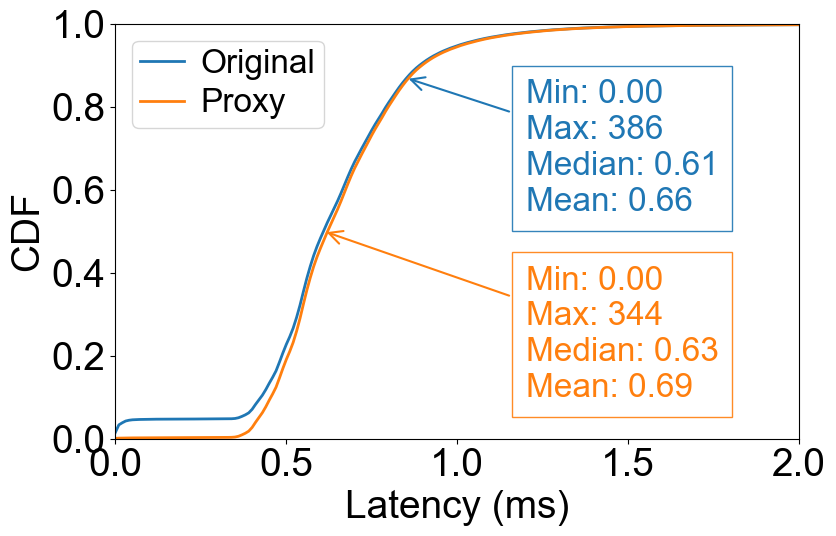

In [3]:
# ====== 4️⃣ 画 CDF 图 ======
plt.figure(figsize=FIGSIZE)

plt.plot(
    x_proxy,
    cdf_proxy,
    linewidth=2,
    label="Original",
    color=colors[0]
)

plt.plot(
    x_proxy_i,
    cdf_proxy_i,
    linewidth=2,
    label="Proxy",
    color=colors[1]
)

plt.xlim(0, 2)        # ✅ 例子：只看 0~5 秒

plt.ylim(0, 1)        # ✅ 例子：只看 0~5 秒

proxy_text = (
    f"Min: {p_min:.2f}\n"
    f"Max: {int(p_max)}\n"
    f"Median: {p_median:.2f}\n"
    f"Mean: {p_mean:.2f}"
)

plt.annotate(
    proxy_text,
    xy=(0.85, 0.87),              # 箭头指向 proxy 的中位数
    xytext=(0.60, 0.55),            # 文本框位置（相对坐标）
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", linewidth=1.5, color=colors[0]),
    bbox=dict(boxstyle="square,pad=0.4", fc="white", ec=colors[0], alpha=0.9),
    fontsize=LEGEND_FONTSIZE,
    color=colors[0]
)

proxy_i_text = (
    f"Min: {pi_min:.2f}\n"
    f"Max: {int(pi_max)}\n"
    f"Median: {pi_median:.2f}\n"
    f"Mean: {pi_mean:.2f}"
)

plt.annotate(
    proxy_i_text,
    xy=(0.61, 0.5),             # 箭头指向 proxy_i 的中位数
    xytext=(0.60, 0.1),             # ✅ 换一个位置，避免重叠
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", linewidth=1.5, color = colors[1] ),
    bbox=dict(boxstyle="square,pad=0.4", fc="white", ec=colors[1], alpha=0.9),
    fontsize=LEGEND_FONTSIZE,
    color=colors[1]
)



# ====== 5️⃣ 坐标轴 & 样式 ======
plt.xlabel("Latency (ms)", fontsize=LABEL_FONTSIZE)
plt.ylabel("CDF", fontsize=LABEL_FONTSIZE)
# plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(
    loc="upper left",          # 左上角对齐锚点
    ncol=1,                    # ✅ 两列排放
    # frameon=True,             # 显示边框
    # bbox_to_anchor=(1.008, -0.03),  # ✅ 控制与图边框的距离（x, y）
    fontsize=LEGEND_FONTSIZE,
    # borderpad=0.6,            # 图例内容与边框的内边距
    # labelspacing=0.2,         # 每一项之间的竖直间距
    columnspacing=0.4,        # 两列之间的水平间距
    # handletextpad=0.6         # marker 与文字之间的间距
)
plt.tight_layout()

plt.savefig(PATH_TO_FIGURES + "overhead_cdf.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()
